In [ ]:
!pip -q install torch torchvision scikit-learn matplotlib seaborn pandas pillow

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.11.0+cpu
CUDA available: False
Device: cpu


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paper-related configuration
IMAGE_SIZE = 128
BATCH_SIZE = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.1
MAX_EPOCHS = 100
LR_GAMMA = 0.8
LR_STEP_SIZE = 3

NUM_CLASSES = 6
N_SPLITS = 10

# Debug mode
FAST_DEBUG_MODE = True
DEBUG_EPOCHS = 2
DEBUG_FOLDS = 1

print("Configuration loaded.")

Configuration loaded.


In [ ]:
# We will upload the NEU dataset directly to this Colab runtime.
print("Drive mounting skipped.")
print("We will upload the dataset directly to Colab.")

Drive mounting skipped.
We will upload the dataset directly to Colab.


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

In [ ]:
import os

print("Files in Colab:")
for file in os.listdir("/content"):
    print(file)

Files in Colab:
.config
NEU-CLS.rar
sample_data


In [ ]:
!apt-get -qq update
!apt-get -qq install unrar

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!mkdir -p /content/NEU-CLS
!unrar x "/content/NEU-CLS.rar" "/content/NEU-CLS/"


UNRAR 7.00 freeware      Copyright (c) 1993-2024 Alexander Roshal


Extracting from /content/NEU-CLS.rar

Creating    /content/NEU-CLS/NEU-CLS                                  OK
Extracting  /content/NEU-CLS/NEU-CLS/Cr_1.bmp                              0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_10.bmp                             0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_100.bmp                            0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_101.bmp                            0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_102.bmp                            0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_103.bmp                            0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_104.bmp                            0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_105.bmp                            0%  OK 
Extracting  /content/NEU-CLS/NEU-CLS/Cr_106.bmp                            0%

In [ ]:
import os

dataset_path = "/content/NEU-CLS/NEU-CLS"

print("Dataset path:", dataset_path)
print("\nFiles/folders inside:")

for item in os.listdir(dataset_path):
    print(item)

Dataset path: /content/NEU-CLS/NEU-CLS

Files/folders inside:
RS_297.bmp
Sc_232.bmp
Pa_271.bmp
RS_190.bmp
RS_237.bmp
In_120.bmp
RS_295.bmp
Sc_69.bmp
Sc_176.bmp
In_213.bmp
Cr_291.bmp
In_221.bmp
Sc_164.bmp
RS_9.bmp
Cr_217.bmp
Sc_258.bmp
RS_283.bmp
Cr_134.bmp
Sc_71.bmp
In_81.bmp
RS_79.bmp
Sc_81.bmp
Cr_299.bmp
Sc_203.bmp
PS_180.bmp
In_173.bmp
Sc_270.bmp
In_294.bmp
RS_174.bmp
PS_271.bmp
PS_233.bmp
Sc_36.bmp
PS_53.bmp
RS_59.bmp
Sc_220.bmp
Sc_107.bmp
Cr_86.bmp
In_54.bmp
Sc_143.bmp
Sc_167.bmp
Pa_92.bmp
Pa_30.bmp
Cr_104.bmp
Pa_260.bmp
RS_211.bmp
Sc_44.bmp
Cr_93.bmp
Pa_68.bmp
Sc_58.bmp
Cr_82.bmp
Pa_112.bmp
Sc_197.bmp
RS_148.bmp
Sc_62.bmp
In_180.bmp
RS_284.bmp
Sc_244.bmp
PS_288.bmp
Sc_259.bmp
Sc_122.bmp
Pa_192.bmp
In_3.bmp
Cr_196.bmp
Cr_139.bmp
PS_8.bmp
PS_139.bmp
In_228.bmp
Pa_288.bmp
PS_201.bmp
Cr_160.bmp
Cr_211.bmp
RS_203.bmp
In_74.bmp
Cr_288.bmp
RS_15.bmp
Cr_33.bmp
Cr_169.bmp
PS_207.bmp
RS_186.bmp
In_45.bmp
PS_76.bmp
RS_48.bmp
In_272.bmp
RS_216.bmp
In_182.bmp
Pa_265.bmp
Pa_279.bmp
Pa_158.bmp


In [ ]:
import os
from PIL import Image

dataset_path = "/content/NEU-CLS/NEU-CLS"

class_mapping = {
    "Cr": 0,   # Crazing
    "In": 1,   # Inclusion
    "Pa": 2,   # Patches
    "PS": 3,   # Pitted Surface
    "RS": 4,   # Rolled-in Scale
    "Sc": 5    # Scratches
}

image_paths = []
labels = []

for filename in os.listdir(dataset_path):
    if filename.lower().endswith((".bmp", ".jpg", ".jpeg", ".png")):
        prefix = filename.split("_")[0]

        if prefix in class_mapping:
            image_paths.append(os.path.join(dataset_path, filename))
            labels.append(class_mapping[prefix])

print("Total images found:", len(image_paths))
print("Total labels:", len(labels))

Total images found: 1800
Total labels: 1800


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class NEUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("L")
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

print("NEU Dataset class created successfully.")

NEU Dataset class created successfully.


In [ ]:
# Paper implementation configuration

IMAGE_SIZE = 128
BATCH_SIZE = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.1
MAX_EPOCHS = 100
LR_GAMMA = 0.8
LR_STEP_SIZE = 3

NUM_CLASSES = 6
N_SPLITS = 10

print("Configuration loaded.")
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Configuration loaded.
Image size: 128
Batch size: 10


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

print("Transform created.")

Transform created.


In [ ]:
neu_dataset = NEUDataset(
    image_paths=image_paths,
    labels=labels,
    transform=transform
)

print("Total samples:", len(neu_dataset))

image, label = neu_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Total samples: 1800
Image shape: torch.Size([1, 128, 128])
Label: 4


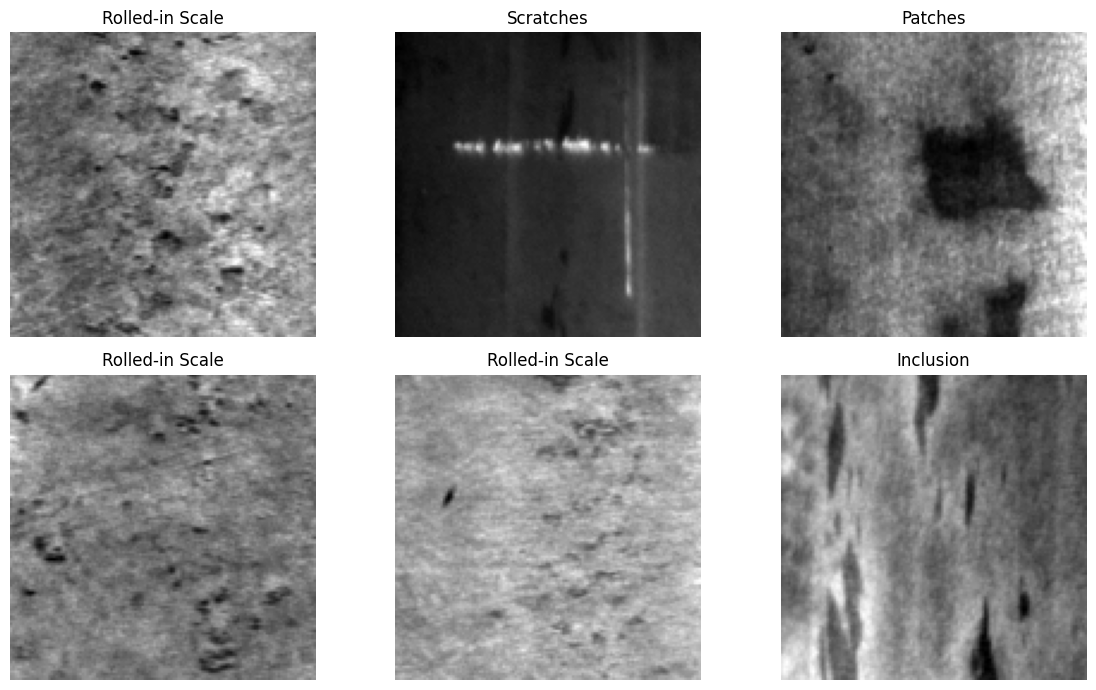

In [ ]:
import matplotlib.pyplot as plt

class_names = [
    "Crazing",
    "Inclusion",
    "Patches",
    "Pitted Surface",
    "Rolled-in Scale",
    "Scratches"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for i, ax in enumerate(axes.flat):
    image, label = neu_dataset[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: Tesla T4


In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock5x5(nn.Module):
    """
    SurfNet 5x5 convolution block:
    Conv2D -> BatchNorm -> PReLU
    """

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=5,
                stride=stride,
                padding=2,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.PReLU(out_channels)
        )

    def forward(self, x):
        return self.block(x)


class ResidualPBlock(nn.Module):
    """
    SurfNet Residual-P block:
    1x1 Conv -> BatchNorm -> PReLU
    with a skip connection.
    """

    def __init__(self, channels):
        super().__init__()

        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )

        self.bn = nn.BatchNorm2d(channels)
        self.prelu = nn.PReLU(channels)

    def forward(self, x):
        residual = x

        out = self.conv(x)
        out = self.bn(out)
        out = self.prelu(out)

        out = out + residual

        return out


print("SurfNet blocks created successfully.")

SurfNet blocks created successfully.


In [ ]:
class SurfNet(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Feature extraction
        self.features = nn.Sequential(
            # SurfNet Block 1
            ConvBlock5x5(1, 32, stride=2),
            ResidualPBlock(32),

            # SurfNet Block 2
            ConvBlock5x5(32, 64, stride=2),
            ResidualPBlock(64),

            # SurfNet Block 3
            ConvBlock5x5(64, 128, stride=2),
            ResidualPBlock(128)
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classification layer
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return F.log_softmax(x, dim=1)


print("SurfNet model class created.")

SurfNet model class created.


In [ ]:
model = SurfNet(num_classes=NUM_CLASSES).to(device)

print(model)

SurfNet(
  (features): Sequential(
    (0): ConvBlock5x5(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=32)
      )
    )
    (1): ResidualPBlock(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (prelu): PReLU(num_parameters=32)
    )
    (2): ConvBlock5x5(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=64)
      )
    )
    (3): ResidualPBlock(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

In [ ]:
dummy_input = torch.randn(1, 1, 128, 128).to(device)

with torch.no_grad():
    output = model(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([1, 1, 128, 128])
Output shape: torch.Size([1, 6])


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 280422
Trainable parameters: 280422


In [23]:
criterion = nn.NLLLoss()

optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)

Loss function : NLLLoss()
Optimizer     : RMSprop
Learning rate : 0.0001
Weight decay  : 0.1


In [24]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=LR_STEP_SIZE,
    gamma=LR_GAMMA
)

print("Scheduler: StepLR")
print("Step size:", LR_STEP_SIZE)
print("Gamma:", LR_GAMMA)

Scheduler: StepLR
Step size: 3
Gamma: 0.8


In [25]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

print("Number of folds:", N_SPLITS)
print("Stratified:", True)

Number of folds: 10
Stratified: True


In [27]:
import numpy as np

print("NumPy imported successfully.")

NumPy imported successfully.


In [28]:
indices = np.arange(len(image_paths))
labels_array = np.array(labels)

train_idx, val_idx = next(
    skf.split(indices, labels_array)
)

print("Training samples  :", len(train_idx))
print("Validation samples:", len(val_idx))

print("\nTraining class distribution:")
print(np.bincount(labels_array[train_idx]))

print("\nValidation class distribution:")
print(np.bincount(labels_array[val_idx]))

Training samples  : 1620
Validation samples: 180

Training class distribution:
[270 270 270 270 270 270]

Validation class distribution:
[30 30 30 30 30 30]


In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training function created successfully.")

Training function created successfully.


In [30]:
def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total

    return val_loss, val_accuracy


print("Validation function created successfully.")

Validation function created successfully.


In [32]:
from torch.utils.data import DataLoader

print("DataLoader imported successfully.")

DataLoader imported successfully.


In [33]:
train_dataset = NEUDataset(
    [image_paths[i] for i in train_idx],
    [labels[i] for i in train_idx],
    transform=transform
)

val_dataset = NEUDataset(
    [image_paths[i] for i in val_idx],
    [labels[i] for i in val_idx],
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches  : 162
Validation batches: 18


In [34]:
# Create a fresh model
debug_model = SurfNet(num_classes=NUM_CLASSES).to(device)

# Loss
debug_criterion = nn.NLLLoss()

# Optimizer
debug_optimizer = torch.optim.RMSprop(
    debug_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Starting debug training...\n")

for epoch in range(2):

    train_loss, train_acc = train_one_epoch(
        debug_model,
        train_loader,
        debug_criterion,
        debug_optimizer,
        device
    )

    val_loss, val_acc = evaluate_model(
        debug_model,
        val_loader,
        debug_criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/2 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

Starting debug training...

Epoch 1/2 | Train Loss: 0.9329 | Train Acc: 69.26% | Val Loss: 0.5744 | Val Acc: 85.56%
Epoch 2/2 | Train Loss: 0.6754 | Train Acc: 77.59% | Val Loss: 0.6062 | Val Acc: 79.44%


In [35]:
# Create a fresh model
debug_model = SurfNet(num_classes=NUM_CLASSES).to(device)

# Loss function
debug_criterion = nn.NLLLoss()

# RMSprop optimizer
debug_optimizer = torch.optim.RMSprop(
    debug_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning-rate scheduler
debug_scheduler = torch.optim.lr_scheduler.StepLR(
    debug_optimizer,
    step_size=LR_STEP_SIZE,
    gamma=LR_GAMMA
)

print("Starting 2-epoch debug training...\n")

for epoch in range(2):

    train_loss, train_acc = train_one_epoch(
        debug_model,
        train_loader,
        debug_criterion,
        debug_optimizer,
        device
    )

    val_loss, val_acc = evaluate_model(
        debug_model,
        val_loader,
        debug_criterion,
        device
    )

    # Update learning rate
    debug_scheduler.step()

    current_lr = debug_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}/2 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.7f}"
    )

Starting 2-epoch debug training...

Epoch 1/2 | Train Loss: 0.9753 | Train Acc: 64.20% | Val Loss: 0.6617 | Val Acc: 76.67% | LR: 0.0001000
Epoch 2/2 | Train Loss: 0.7308 | Train Acc: 76.17% | Val Loss: 0.6297 | Val Acc: 77.22% | LR: 0.0001000


In [36]:
def train_fold(
    train_idx,
    val_idx,
    fold_number,
    num_epochs=100
):

    # -----------------------------
    # Create datasets
    # -----------------------------
    train_dataset = NEUDataset(
        [image_paths[i] for i in train_idx],
        [labels[i] for i in train_idx],
        transform=transform
    )

    val_dataset = NEUDataset(
        [image_paths[i] for i in val_idx],
        [labels[i] for i in val_idx],
        transform=transform
    )

    # -----------------------------
    # Create DataLoaders
    # -----------------------------
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    # -----------------------------
    # Fresh model
    # -----------------------------
    model = SurfNet(num_classes=NUM_CLASSES).to(device)

    # -----------------------------
    # Loss
    # -----------------------------
    criterion = nn.NLLLoss()

    # -----------------------------
    # Optimizer
    # -----------------------------
    optimizer = torch.optim.RMSprop(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # -----------------------------
    # Scheduler
    # -----------------------------
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=LR_STEP_SIZE,
        gamma=LR_GAMMA
    )

    # -----------------------------
    # Store history
    # -----------------------------
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    best_val_acc = 0.0
    best_state = None

    print(f"\n========== Fold {fold_number} ==========")

    # -----------------------------
    # Training
    # -----------------------------
    for epoch in range(num_epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        # Save history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Save best model state
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | "
            f"Train Acc: {train_acc*100:.2f}% | "
            f"Val Acc: {val_acc*100:.2f}% | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"LR: {current_lr:.7f}"
        )

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    print(
        f"Best validation accuracy for Fold {fold_number}: "
        f"{best_val_acc*100:.2f}%"
    )

    return model, history, best_val_acc

In [37]:
debug_model, debug_history, debug_best_acc = train_fold(
    train_idx=train_idx,
    val_idx=val_idx,
    fold_number=1,
    num_epochs=2
)

print("\nDebug run completed.")
print(f"Best validation accuracy: {debug_best_acc * 100:.2f}%")


========== Fold 1 ==========
Epoch 001/2 | Train Acc: 64.88% | Val Acc: 81.67% | Train Loss: 1.0299 | Val Loss: 0.6467 | LR: 0.0001000
Epoch 002/2 | Train Acc: 76.73% | Val Acc: 63.89% | Train Loss: 0.7407 | Val Loss: 0.9888 | LR: 0.0001000
Best validation accuracy for Fold 1: 81.67%

Debug run completed.
Best validation accuracy: 81.67%


In [38]:
# ==========================================
# 10-FOLD STRATIFIED CROSS-VALIDATION
# ==========================================

indices = np.arange(len(image_paths))
labels_array = np.array(labels)

fold_results = []
all_histories = []

print("Starting 10-Fold Cross-Validation")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(indices, labels_array), start=1
):

    print(f"\n\n{'='*20} FOLD {fold}/{N_SPLITS} {'='*20}")

    # Train this fold
    model, history, best_acc = train_fold(
        train_idx=train_idx,
        val_idx=val_idx,
        fold_number=fold,
        num_epochs=MAX_EPOCHS
    )

    # Store results
    fold_results.append(best_acc)
    all_histories.append(history)

    print(
        f"\nFold {fold} completed."
        f"\nBest validation accuracy: {best_acc * 100:.2f}%"
    )

    # Clear GPU memory before next fold
    del model
    torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("10-FOLD CROSS-VALIDATION COMPLETED")
print("=" * 60)

Starting 10-Fold Cross-Validation


==================== FOLD 1/10 ====================

========== Fold 1 ==========
Epoch 001/100 | Train Acc: 64.26% | Val Acc: 72.22% | Train Loss: 1.0099 | Val Loss: 0.7568 | LR: 0.0001000
Epoch 002/100 | Train Acc: 78.46% | Val Acc: 73.33% | Train Loss: 0.6918 | Val Loss: 0.6712 | LR: 0.0001000
Epoch 003/100 | Train Acc: 80.31% | Val Acc: 88.89% | Train Loss: 0.6038 | Val Loss: 0.3912 | LR: 0.0000800
Epoch 004/100 | Train Acc: 83.95% | Val Acc: 89.44% | Train Loss: 0.5155 | Val Loss: 0.3909 | LR: 0.0000800
Epoch 005/100 | Train Acc: 86.30% | Val Acc: 91.67% | Train Loss: 0.4484 | Val Loss: 0.3299 | LR: 0.0000800
Epoch 006/100 | Train Acc: 86.11% | Val Acc: 92.78% | Train Loss: 0.4486 | Val Loss: 0.2882 | LR: 0.0000640
Epoch 007/100 | Train Acc: 89.07% | Val Acc: 93.33% | Train Loss: 0.3847 | Val Loss: 0.2563 | LR: 0.0000640
Epoch 008/100 | Train Acc: 89.20% | Val Acc: 93.89% | Train Loss: 0.3739 | Val Loss: 0.2383 | LR: 0.0000640
Epoch 009/100 | Tr

In [39]:
import numpy as np

fold_results = np.array(fold_results)

print("Individual Fold Accuracies:")
for i, acc in enumerate(fold_results, start=1):
    print(f"Fold {i}: {acc * 100:.2f}%")

mean_accuracy = fold_results.mean()
std_accuracy = fold_results.std()

print("\n" + "=" * 50)
print(f"Mean Accuracy: {mean_accuracy * 100:.2f}%")
print(f"Std Deviation: {std_accuracy * 100:.2f}%")
print("=" * 50)

Individual Fold Accuracies:
Fold 1: 99.44%
Fold 2: 100.00%
Fold 3: 99.44%
Fold 4: 100.00%
Fold 5: 98.33%
Fold 6: 99.44%
Fold 7: 99.44%
Fold 8: 99.44%
Fold 9: 98.89%
Fold 10: 99.44%

Mean Accuracy: 99.39%
Std Deviation: 0.46%


In [40]:
import pandas as pd

results_df = pd.DataFrame({
    "Fold": np.arange(1, len(fold_results) + 1),
    "Best_Validation_Accuracy": fold_results
})

results_df["Accuracy_Percent"] = (
    results_df["Best_Validation_Accuracy"] * 100
)

results_df

,Fold,Best_Validation_Accuracy,Accuracy_Percent
0,1,0.994444,99.444444
1,2,1.000000,100.000000
2,3,0.994444,99.444444
3,4,1.000000,100.000000
4,5,0.983333,98.333333
5,6,0.994444,99.444444
6,7,0.994444,99.444444
7,8,0.994444,99.444444
8,9,0.988889,98.888889
9,10,0.994444,99.444444


In [41]:
results_df.to_csv(
    "/content/surfnet_10fold_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [42]:
from google.colab import files

files.download("/content/surfnet_10fold_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# ==========================================
# FINAL MODEL FOR PREDICTION
# ==========================================

final_model = SurfNet(num_classes=NUM_CLASSES).to(device)

final_criterion = nn.NLLLoss()

final_optimizer = torch.optim.RMSprop(
    final_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

final_scheduler = torch.optim.lr_scheduler.StepLR(
    final_optimizer,
    step_size=LR_STEP_SIZE,
    gamma=LR_GAMMA
)

# Complete dataset
final_dataset = NEUDataset(
    image_paths,
    labels,
    transform=transform
)

final_loader = DataLoader(
    final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Final model created.")
print("Total training images:", len(final_dataset))

Final model created.
Total training images: 1800


In [44]:
FINAL_EPOCHS = MAX_EPOCHS

final_history = {
    "loss": [],
    "accuracy": [],
    "lr": []
}

print("Starting final model training...\n")

for epoch in range(FINAL_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        final_model,
        final_loader,
        final_criterion,
        final_optimizer,
        device
    )

    final_scheduler.step()

    current_lr = final_optimizer.param_groups[0]["lr"]

    final_history["loss"].append(train_loss)
    final_history["accuracy"].append(train_acc)
    final_history["lr"].append(current_lr)

    print(
        f"Epoch {epoch+1:03d}/{FINAL_EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: {train_acc*100:.2f}% | "
        f"LR: {current_lr:.7f}"
    )

Starting final model training...

Epoch 001/100 | Loss: 0.9839 | Accuracy: 64.78% | LR: 0.0001000
Epoch 002/100 | Loss: 0.6842 | Accuracy: 77.67% | LR: 0.0001000
Epoch 003/100 | Loss: 0.6026 | Accuracy: 80.56% | LR: 0.0000800
Epoch 004/100 | Loss: 0.4949 | Accuracy: 84.94% | LR: 0.0000800
Epoch 005/100 | Loss: 0.4373 | Accuracy: 87.11% | LR: 0.0000800
Epoch 006/100 | Loss: 0.4171 | Accuracy: 88.06% | LR: 0.0000640
Epoch 007/100 | Loss: 0.3705 | Accuracy: 90.28% | LR: 0.0000640
Epoch 008/100 | Loss: 0.3356 | Accuracy: 91.22% | LR: 0.0000640
Epoch 009/100 | Loss: 0.3134 | Accuracy: 91.06% | LR: 0.0000512
Epoch 010/100 | Loss: 0.3441 | Accuracy: 90.39% | LR: 0.0000512
Epoch 011/100 | Loss: 0.2734 | Accuracy: 93.50% | LR: 0.0000512
Epoch 012/100 | Loss: 0.2673 | Accuracy: 93.28% | LR: 0.0000410
Epoch 013/100 | Loss: 0.2698 | Accuracy: 93.17% | LR: 0.0000410
Epoch 014/100 | Loss: 0.2587 | Accuracy: 93.89% | LR: 0.0000410
Epoch 015/100 | Loss: 0.2530 | Accuracy: 93.61% | LR: 0.0000328
Epoch 

In [45]:
# ==========================================
# SAVE FINAL SURFNET MODEL
# ==========================================

MODEL_PATH = "/content/SurfNet_NEU.pth"

torch.save(
    final_model.state_dict(),
    MODEL_PATH
)

print("Model saved successfully!")
print("Path:", MODEL_PATH)

Model saved successfully!
Path: /content/SurfNet_NEU.pth


In [46]:
import os

if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

    print("Model file found.")
    print(f"File size: {size_mb:.2f} MB")
else:
    print("Model file not found.")

Model file found.
File size: 1.09 MB


In [47]:
from google.colab import files

files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# ==========================================
# GET PREDICTIONS FROM FINAL MODEL
# ==========================================

final_model.eval()

evaluation_loader = DataLoader(
    final_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

all_true = []
all_pred = []

with torch.no_grad():
    for images, labels_batch in evaluation_loader:
        images = images.to(device)

        outputs = final_model(images)
        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_pred.extend(predictions)
        all_true.extend(labels_batch.numpy())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

print("Total predictions:", len(all_pred))
print("Total true labels:", len(all_true))

Total predictions: 1800
Total true labels: 1800


In [49]:
from sklearn.metrics import classification_report

class_names = [
    "Crazing",
    "Inclusion",
    "Patches",
    "Pitted Surface",
    "Rolled-in Scale",
    "Scratches"
]

print(
    classification_report(
        all_true,
        all_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

        Crazing     1.0000    1.0000    1.0000       300
      Inclusion     0.9709    1.0000    0.9852       300
        Patches     1.0000    1.0000    1.0000       300
 Pitted Surface     1.0000    0.9933    0.9967       300
Rolled-in Scale     1.0000    1.0000    1.0000       300
      Scratches     1.0000    0.9767    0.9882       300

       accuracy                         0.9950      1800
      macro avg     0.9951    0.9950    0.9950      1800
   weighted avg     0.9951    0.9950    0.9950      1800



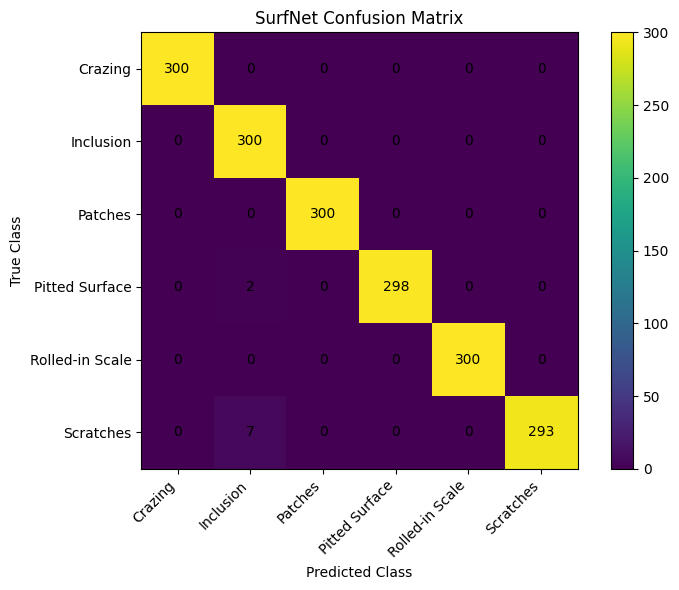

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_true,
    all_pred,
    labels=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("SurfNet Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

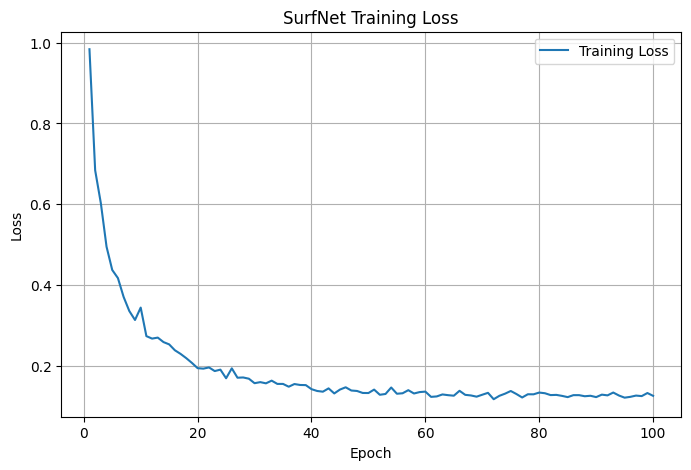

In [51]:
import matplotlib.pyplot as plt

epochs = range(1, len(final_history["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    final_history["loss"],
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SurfNet Training Loss")
plt.legend()
plt.grid(True)

plt.show()

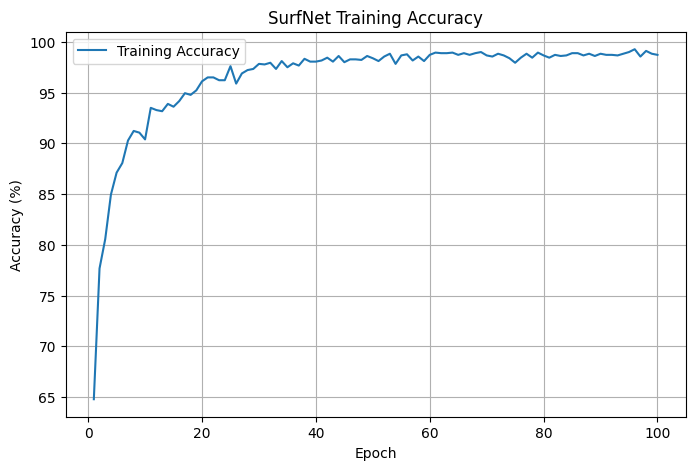

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    np.array(final_history["accuracy"]) * 100,
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("SurfNet Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()

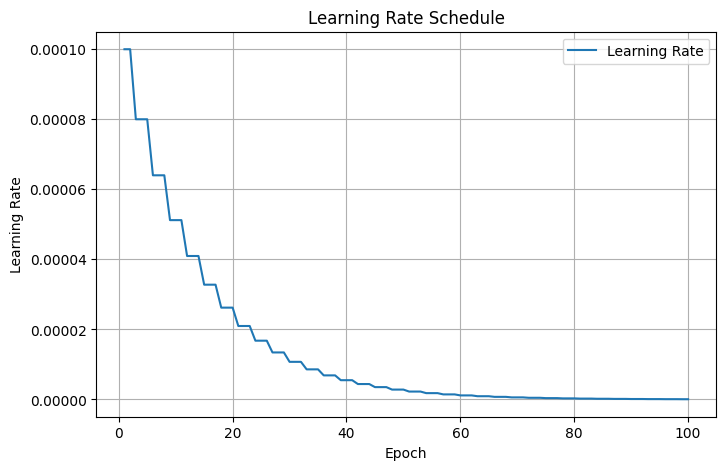

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    final_history["lr"],
    label="Learning Rate"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.grid(True)

plt.show()

Saving Screenshot 2026-09-22 104806.png to Screenshot 2026-09-22 104806.png


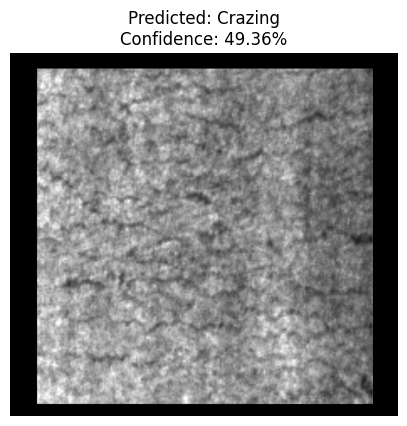

Image: Screenshot 2026-09-22 104806.png
Predicted defect: Crazing
Confidence: 49.36%


In [55]:
from google.colab import files
from PIL import Image
import torch
import matplotlib.pyplot as plt

class_names = [
    "Crazing",
    "Inclusion",
    "Patches",
    "Pitted Surface",
    "Rolled-in Scale",
    "Scratches"
]

# Upload an image
uploaded = files.upload()

# Get uploaded filename
image_name = list(uploaded.keys())[0]

# Open image
image = Image.open(image_name).convert("L")

# Apply the same preprocessing used during training
processed_image = transform(image).unsqueeze(0).to(device)

# Prediction
final_model.eval()

with torch.no_grad():
    output = final_model(processed_image)

    probabilities = torch.softmax(output, dim=1)

    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.show()

print("Image:", image_name)
print("Predicted defect:", class_names[predicted_class])
print(f"Confidence: {confidence * 100:.2f}%")

In [56]:
# ==========================================
# FINAL 10-FOLD RESULTS TABLE
# ==========================================

results_df = pd.DataFrame({
    "Fold": range(1, len(fold_results) + 1),
    "Accuracy (%)": fold_results * 100
})

print(results_df.to_string(index=False))

print("\n" + "=" * 45)
print(f"Mean Accuracy : {fold_results.mean() * 100:.2f}%")
print(f"Std Deviation : {fold_results.std() * 100:.2f}%")
print("=" * 45)

 Fold  Accuracy (%)
    1     99.444444
    2    100.000000
    3     99.444444
    4    100.000000
    5     98.333333
    6     99.444444
    7     99.444444
    8     99.444444
    9     98.888889
   10     99.444444

Mean Accuracy : 99.39%
Std Deviation : 0.46%


In [57]:
results_df.to_csv(
    "/content/SurfNet_10Fold_Final_Results.csv",
    index=False
)

print("Final results CSV saved.")

Final results CSV saved.


In [58]:
comparison_data = {
    "Parameter": [
        "Research Paper",
        "Dataset",
        "Number of Classes",
        "Input Image",
        "Framework",
        "Model",
        "Loss Function",
        "Optimizer",
        "Learning Rate",
        "Weight Decay",
        "Batch Size",
        "Cross-Validation",
        "Our Result"
    ],

    "Value": [
        "Arikan, Varanasi & Stricker (2019)",
        "NEU-CLS for our reproducible experiment",
        "6",
        "128 × 128 grayscale",
        "PyTorch",
        "SurfNet-style CNN",
        "NLLLoss",
        "RMSprop",
        "0.0001",
        "0.1",
        "10",
        "10-fold Stratified",
        f"{fold_results.mean()*100:.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Parameter,Value
0,Research Paper,"Arikan, Varanasi & Stricker (2019)"
1,Dataset,NEU-CLS for our reproducible experiment
2,Number of Classes,6
3,Input Image,128 × 128 grayscale
4,Framework,PyTorch
5,Model,SurfNet-style CNN
6,Loss Function,NLLLoss
7,Optimizer,RMSprop
8,Learning Rate,0.0001
9,Weight Decay,0.1


In [59]:
comparison_df.to_csv(
    "/content/SurfNet_Paper_Implementation_Comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


In [60]:
print("=" * 55)
print("SURFNET — 10-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)

for i, acc in enumerate(fold_results, start=1):
    print(f"Fold {i:2d}: {acc * 100:.2f}%")

print("-" * 55)
print(f"Mean Accuracy : {fold_results.mean() * 100:.2f}%")
print(f"Std Deviation : {fold_results.std() * 100:.2f}%")
print(f"Minimum       : {fold_results.min() * 100:.2f}%")
print(f"Maximum       : {fold_results.max() * 100:.2f}%")
print("=" * 55)

SURFNET — 10-FOLD CROSS-VALIDATION RESULTS
Fold  1: 99.44%
Fold  2: 100.00%
Fold  3: 99.44%
Fold  4: 100.00%
Fold  5: 98.33%
Fold  6: 99.44%
Fold  7: 99.44%
Fold  8: 99.44%
Fold  9: 98.89%
Fold 10: 99.44%
-------------------------------------------------------
Mean Accuracy : 99.39%
Std Deviation : 0.46%
Minimum       : 98.33%
Maximum       : 100.00%


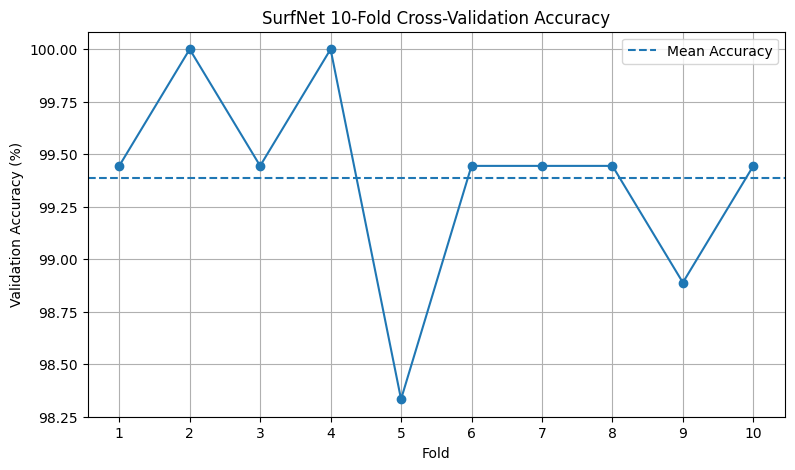

In [61]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(fold_results) + 1),
    fold_results * 100,
    marker="o"
)

plt.axhline(
    fold_results.mean() * 100,
    linestyle="--",
    label="Mean Accuracy"
)

plt.xlabel("Fold")
plt.ylabel("Validation Accuracy (%)")
plt.title("SurfNet 10-Fold Cross-Validation Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()